# Week 3, Part 2: Advanced Exploratory Data Analysis
**AnalystLab Africa, Data Science Internship Programme**
**Project: Employee Attrition Analysis, ABC Manufacturing Ltd**

This notebook goes beyond Week 1's foundational EDA to investigate more complex relationships:
correlations across the full feature set, multivariate patterns, and variables not explored in Week 1
(tenure, promotion history, satisfaction, job-hopping history, commute distance).

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

sns.set_style("whitegrid")
df = pd.read_csv('cleaned_dataset.csv')
df['AttritionNum'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionNum
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,2,0,7,3,3,0,0,0,0,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,0,8,3,3,8,7,3,0,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,4,1,6,3,3,2,2,2,2,0


## 1. Correlation Heatmap (Multivariate Analysis)

A single view across every numeric feature at once, useful for spotting both strong relationships
with Attrition and potential redundancy between predictor variables (relevant later for Part 5,
Feature Evaluation).

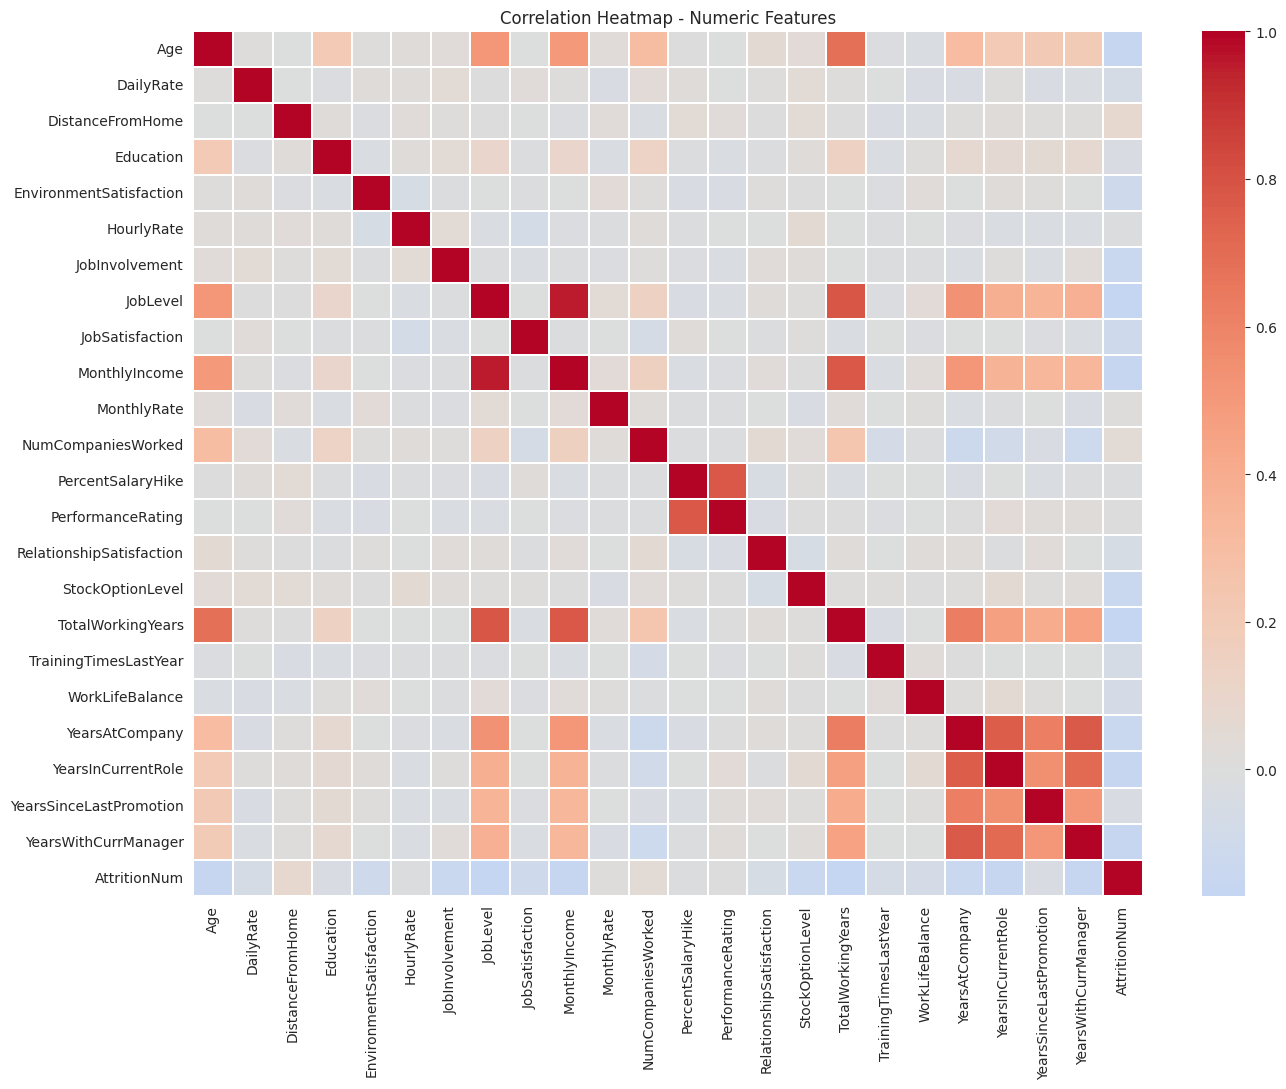

Top correlations with Attrition:
AttritionNum            1.000000
TotalWorkingYears      -0.171063
JobLevel               -0.169105
YearsInCurrentRole     -0.160545
MonthlyIncome          -0.159840
Age                    -0.159205
YearsWithCurrManager   -0.156199
StockOptionLevel       -0.137145
YearsAtCompany         -0.134392
JobInvolvement         -0.130016
Name: AttritionNum, dtype: float64


In [2]:
plt.figure(figsize=(14,11))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.show()

corr_target = corr['AttritionNum'].sort_values(key=abs, ascending=False)
print("Top correlations with Attrition:")
print(corr_target.head(10))

**Interpretation:** TotalWorkingYears (-0.17), JobLevel (-0.17), YearsInCurrentRole (-0.16),
MonthlyIncome (-0.16), and Age (-0.16) show the strongest linear relationships with Attrition, all
negative, meaning more experience, higher job level, longer tenure, higher income, and older age are
all associated with *lower* attrition. No single feature dominates; the relationship is spread across
several moderately correlated, career-stage-related variables rather than one overwhelming factor.

## 2. OverTime Rate by Department (Bivariate: Categorical x Categorical)

Directly investigates the Week 3 hypothesis tested statistically in Part 3: does Sales have a
disproportionately high overtime rate compared to other departments?

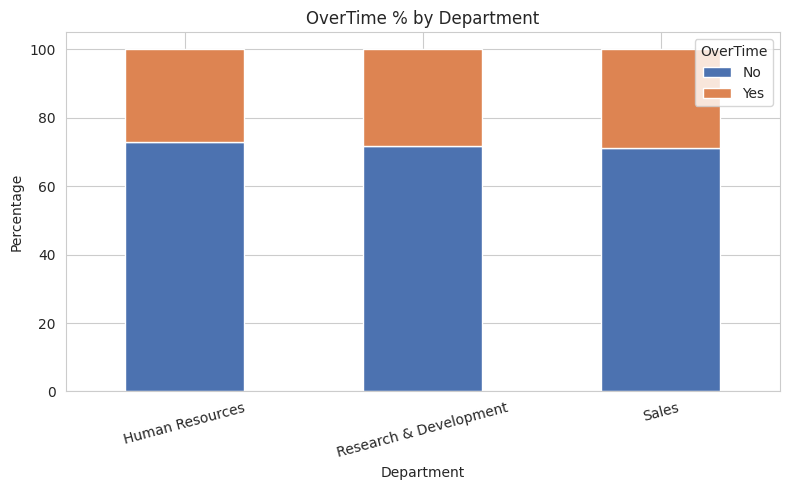

OverTime                       No        Yes
Department                                  
Human Resources         73.015873  26.984127
Research & Development  71.800208  28.199792
Sales                   71.300448  28.699552


In [3]:
plt.figure(figsize=(8,5))
ct = pd.crosstab(df['Department'], df['OverTime'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#4C72B0','#DD8452'])
plt.title('OverTime % by Department')
plt.ylabel('Percentage')
plt.xticks(rotation=15)
plt.legend(title='OverTime')
plt.tight_layout()
plt.show()
print(ct)

**Interpretation:** OverTime rates are nearly identical across all three departments (~27-29%).
This visually confirms the Chi-Square test result from Part 3 (p = 0.9543): Sales' higher attrition
rate is not explained by a higher overtime rate.

## 3. Monthly Income by Job Role (Bivariate: Numerical x Categorical)

Supports the Kruskal-Wallis test from Part 3, showing the full income distribution per role rather
than just the median.

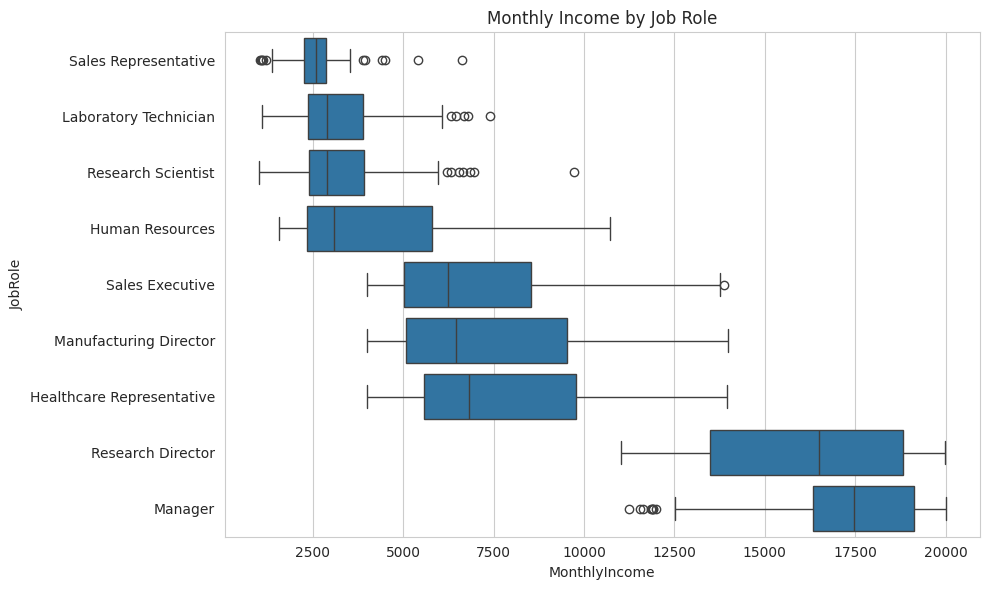

In [4]:
plt.figure(figsize=(10,6))
order = df.groupby('JobRole')['MonthlyIncome'].median().sort_values().index
sns.boxplot(data=df, y='JobRole', x='MonthlyIncome', order=order)
plt.title('Monthly Income by Job Role')
plt.tight_layout()
plt.show()

**Interpretation:** Sales Representative sits clearly at the bottom of the income distribution,
with a visibly lower box and whiskers than every other role, including other entry-level-seeming roles
like Laboratory Technician and Research Scientist. This visually reinforces Test 4's statistically
significant result.

## 4. Work-Life Balance by Attrition (Violin Plot)

A richer alternative to a boxplot, showing the full shape of the distribution rather than only
quartiles.

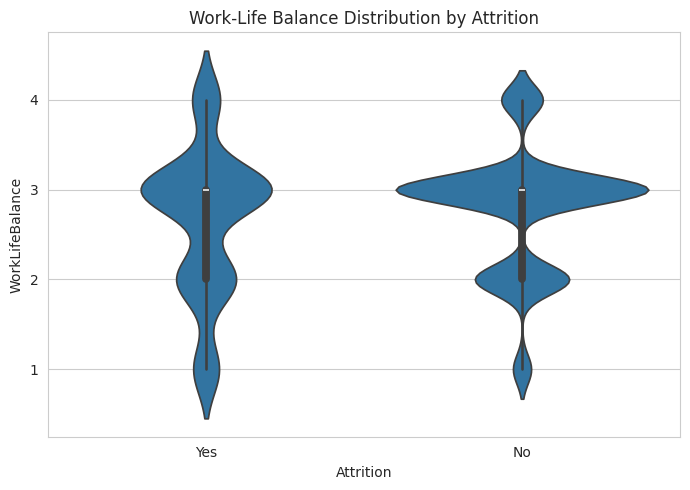

Attrition
No     2.781022
Yes    2.658228
Name: WorkLifeBalance, dtype: float64


In [5]:
plt.figure(figsize=(7,5))
sns.violinplot(data=df, x='Attrition', y='WorkLifeBalance')
plt.title('Work-Life Balance Distribution by Attrition')
plt.tight_layout()
plt.show()

print(df.groupby('Attrition')['WorkLifeBalance'].mean())

**Interpretation:** Employees who left have a slightly lower average Work-Life Balance score
(2.66 vs 2.78) and the violin shape shows more density at the lower end (score 1) for the "Yes" group.
The difference is real but modest, suggesting work-life balance plays a secondary, contributing role
alongside stronger factors like income and age rather than being a primary driver on its own.

## 5. Age vs Monthly Income, Colored by Attrition (Multivariate Scatter Plot)

Examines two of the strongest attrition-linked variables together.

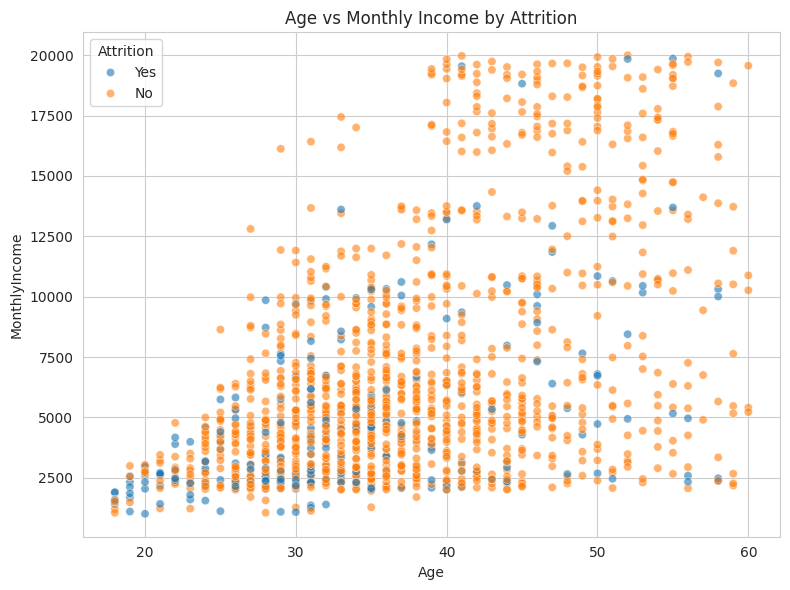

In [6]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Age', y='MonthlyIncome', hue='Attrition', alpha=0.6)
plt.title('Age vs Monthly Income by Attrition')
plt.tight_layout()
plt.show()

**Interpretation:** Attrition (orange points) is heavily concentrated in the lower-left region
of the plot, younger *and* lower-income simultaneously, rather than being explained by either variable
alone. This suggests age and income may interact: young, low-paid employees appear to be the
highest-risk combination, more so than either factor independently.

## 6. Number of Previous Companies Worked vs Attrition (New Variable, Not Explored in Week 1)

Investigates whether a history of frequent job changes ("job hopping") is associated with attrition
here as well.

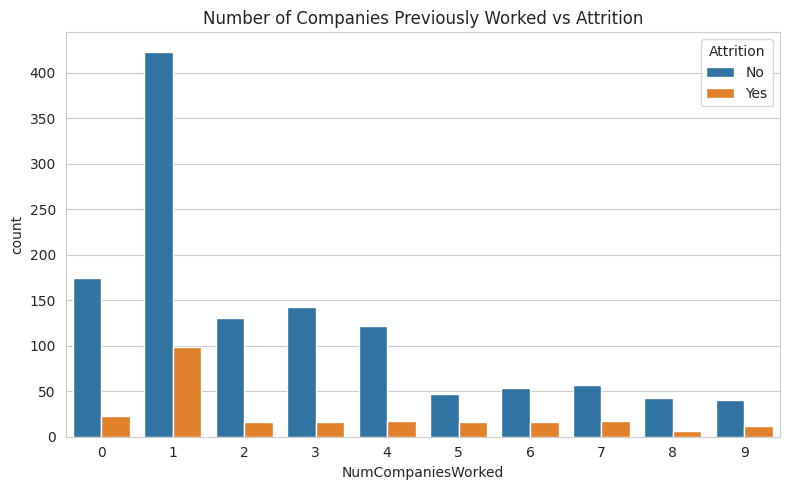

Attrition
No     2.645580
Yes    2.940928
Name: NumCompaniesWorked, dtype: float64


In [7]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='NumCompaniesWorked', hue='Attrition')
plt.title('Number of Companies Previously Worked vs Attrition')
plt.tight_layout()
plt.show()

print(df.groupby('Attrition')['NumCompaniesWorked'].mean())

**Interpretation:** Employees who left worked at slightly more previous companies on average
(2.94 vs 2.65), a modest but present difference. This is a mild signal that some attrition may reflect
a pre-existing pattern of shorter tenures, rather than something ABC Manufacturing Ltd caused, worth
noting as a nuance for the Business Insights Report.

## 7. Years Since Last Promotion, Density by Attrition (New Variable)

Tests whether promotion stagnation, one of the Week 2 engineered feature concepts, shows a visible
pattern.

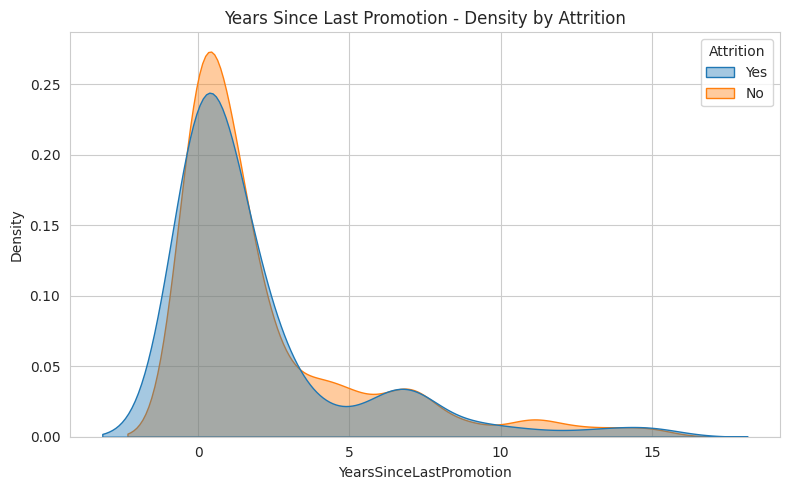

Attrition
No     2.234388
Yes    1.945148
Name: YearsSinceLastPromotion, dtype: float64


In [8]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='YearsSinceLastPromotion', hue='Attrition', fill=True, common_norm=False, alpha=0.4)
plt.title('Years Since Last Promotion - Density by Attrition')
plt.tight_layout()
plt.show()

print(df.groupby('Attrition')['YearsSinceLastPromotion'].mean())

**Interpretation:** Counter-intuitively, employees who left have a slightly *lower* average
years since last promotion (1.95 vs 2.23), not higher. This means promotion stagnation, at least as
measured here, is not a driver of attrition in this dataset. This is a useful negative finding: it
means the PromotionStagnationRatio feature engineered in Week 2 should be evaluated carefully rather
than assumed to be predictive (revisited in Part 5).

## 8. Monthly Income Distribution and Skewness (Numerical Analysis)

Formally quantifies the right-skew in income already observed and confirmed statistically (Shapiro-Wilk)
in Part 3.

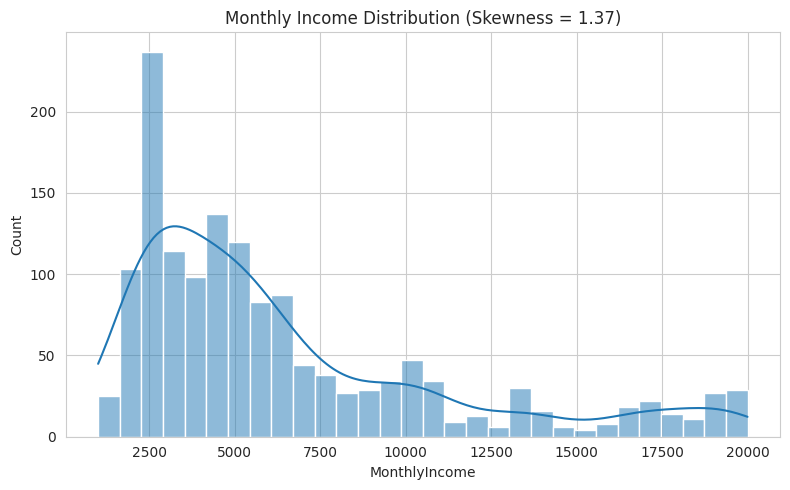

Skewness: 1.3684185123330814


In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyIncome'], bins=30, kde=True)
skew_val = skew(df['MonthlyIncome'])
plt.title(f'Monthly Income Distribution (Skewness = {skew_val:.2f})')
plt.tight_layout()
plt.show()
print("Skewness:", skew_val)

**Interpretation:** A skewness value of 1.37 confirms strong right-skew (a skewness of 0 would
indicate a symmetric distribution). This is why Mann-Whitney U, not a t-test, was the correct choice
in Part 3, and is also a strong candidate for a log transformation if MonthlyIncome is used directly
in a future predictive model.

## 9. Distance From Home by Attrition (New Variable)

Tests whether commute distance plays a role, a factor not examined in Week 1.

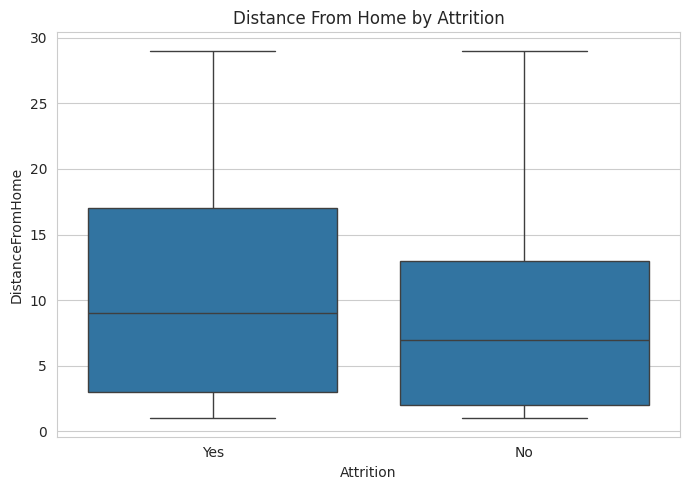

Attrition
No      8.915653
Yes    10.632911
Name: DistanceFromHome, dtype: float64


In [10]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Attrition', y='DistanceFromHome')
plt.title('Distance From Home by Attrition')
plt.tight_layout()
plt.show()

print(df.groupby('Attrition')['DistanceFromHome'].mean())

**Interpretation:** Employees who left live further from work on average (10.6 vs 8.9 units).
The difference is modest but consistent with intuition, a longer commute is a plausible, minor
contributing factor to dissatisfaction and eventual attrition.

## 10. Pair Plot: Age, Income, Experience, Tenure by Attrition (Multivariate)

A compact way to view every pairwise relationship among four key numeric variables at once, colored
by the target variable.

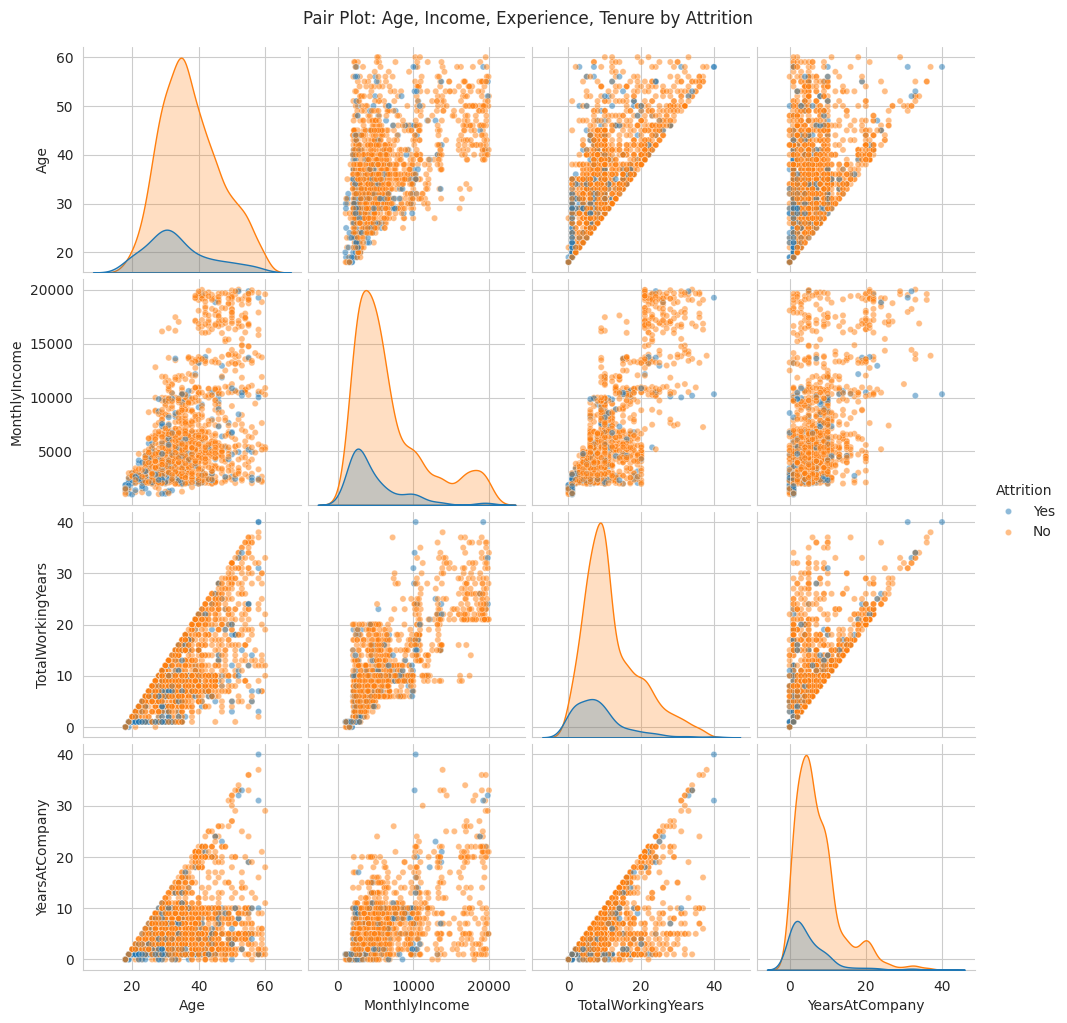

In [11]:
subset = df[['Age','MonthlyIncome','TotalWorkingYears','YearsAtCompany','Attrition']]
g = sns.pairplot(subset, hue='Attrition', diag_kind='kde', plot_kws={'alpha':0.5, 's':20})
g.fig.suptitle('Pair Plot: Age, Income, Experience, Tenure by Attrition', y=1.02)
plt.show()

**Interpretation:** Across every pairing, the "Yes" (attrition) points cluster toward the lower
end of age, income, experience, and tenure simultaneously. No single scatter panel shows a clean
separation on its own, reinforcing that attrition here is best explained by a *combination* of
career-stage-related factors rather than any one variable in isolation.

## 11. Attrition Rate by Job Role and Department (Pivot Table Heatmap)

Combines two categorical variables against the target, extending the Week 1 department-level and
role-level findings into a single cross-tabulated view.

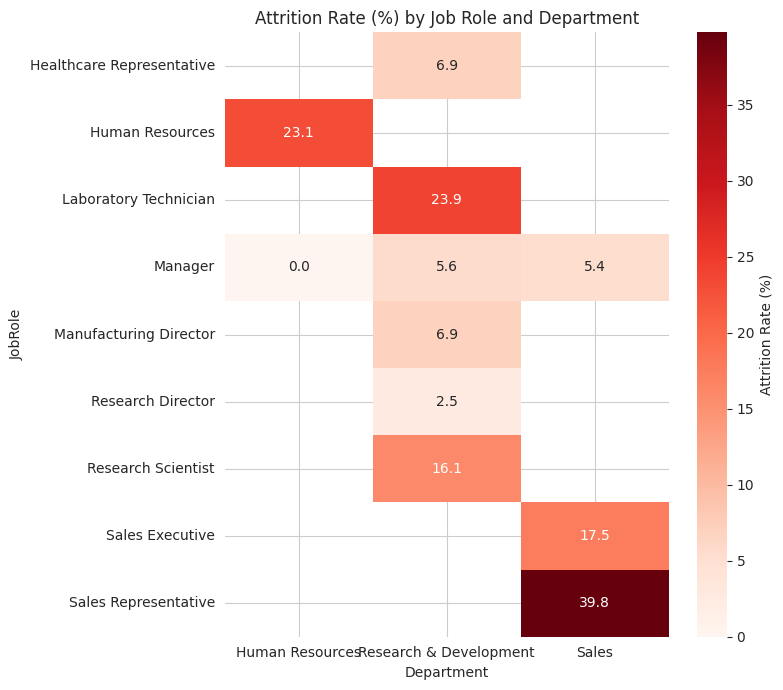

In [12]:
pivot = df.pivot_table(values='AttritionNum', index='JobRole', columns='Department', aggfunc='mean') * 100
plt.figure(figsize=(8,7))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label':'Attrition Rate (%)'})
plt.title('Attrition Rate (%) by Job Role and Department')
plt.tight_layout()
plt.show()

**Interpretation:** Sales Representative (within Sales) stands out sharply at 39.8%, the single
highest cell in the entire matrix, well above every other Job Role/Department combination (the next
highest, Laboratory Technician in R&D, sits at 23.9%). This confirms visually that attrition risk is
concentrated in one specific role, not spread evenly across a department.

## 12. Total Working Years vs Years at Company, Colored by Attrition

Examines whether attrition is linked to a mismatch between total career length and time spent
specifically at this company.

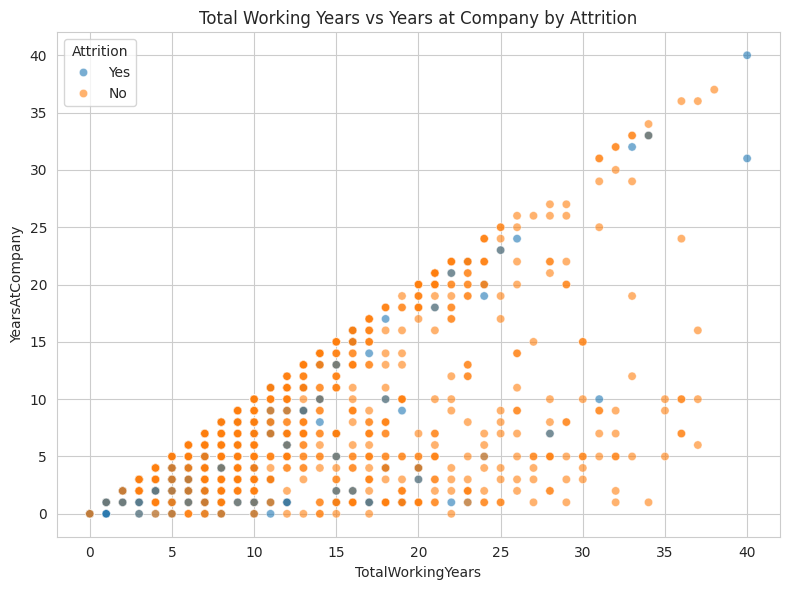

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='TotalWorkingYears', y='YearsAtCompany', hue='Attrition', alpha=0.6)
plt.title('Total Working Years vs Years at Company by Attrition')
plt.tight_layout()
plt.show()

**Interpretation:** Attrition cases cluster toward the lower-left, employees with both less
total career experience and less time at this specific company. There is no visible cluster of
attrition among employees with high total experience but low company tenure (which would have
suggested "experienced hires leaving early"), suggesting this dataset's attrition is more about
overall career stage than about a company-specific mismatch.

## 13. Job Satisfaction Level by Attrition (Categorical Group Comparison)

Tests whether self-reported job satisfaction shows a clear gradient against attrition.

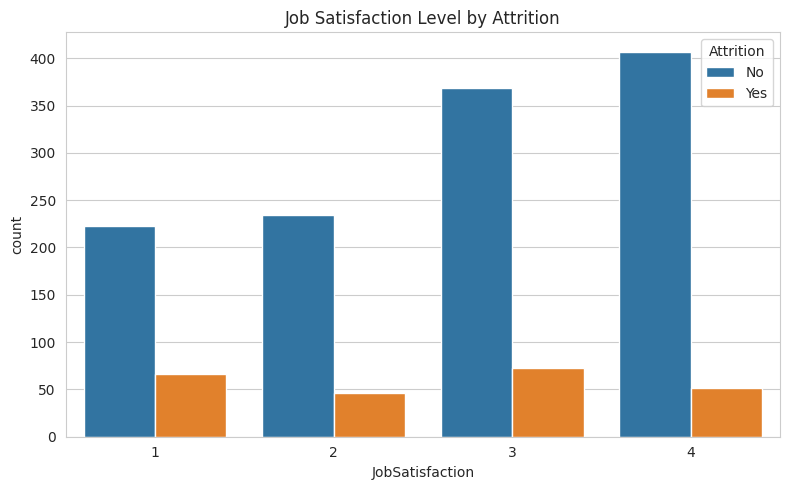

Attrition               No        Yes
JobSatisfaction                      
1                77.162630  22.837370
2                83.571429  16.428571
3                83.484163  16.515837
4                88.671024  11.328976


In [14]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='JobSatisfaction', hue='Attrition')
plt.title('Job Satisfaction Level by Attrition')
plt.tight_layout()
plt.show()

js_rate = pd.crosstab(df['JobSatisfaction'], df['Attrition'], normalize='index') * 100
print(js_rate)

**Interpretation:** There is a clear, consistent gradient: attrition rate falls from 22.8% at the
lowest satisfaction level (1) down to 11.3% at the highest (4), roughly halving. This is one of the
cleanest, most linear patterns found in the advanced EDA, and a strong candidate feature for Week 4's
predictive model.

## Summary of Advanced EDA Findings

- **Confirmed department-level finding**: OverTime is evenly distributed across departments (~27-29%),
  ruling it out as the explanation for Sales' higher attrition, consistent with Part 3's Chi-Square test.
- **Confirmed role-level finding**: Sales Representative has both the lowest median income and the
  highest attrition rate of any role/department combination in the entire dataset (39.8%).
- **New pattern found**: Attrition is not explained by any single variable in isolation, but by a
  cluster of related, lower career-stage indicators (younger age, lower income, less experience, less
  tenure) appearing together, visible clearly in the pair plot and the age/income scatter plot.
- **New pattern found**: Job Satisfaction shows a clean, roughly linear relationship with attrition
  (22.8% down to 11.3% across the four satisfaction levels).
- **New, counter-intuitive finding**: Promotion stagnation (YearsSinceLastPromotion) is *not* linked to
  higher attrition in this dataset, employees who left actually had slightly fewer years since their
  last promotion on average.
- **Minor contributing factors identified**: commute distance (DistanceFromHome) and prior job-hopping
  history (NumCompaniesWorked) both show small but consistent differences between employees who left
  and stayed.
